### `time_to_pressure` Survival Analysis (Use case E)
#### How long does a block last — not just whether it fails?

**Pipeline:** Raw `pffScoutingData.csv` + `tracking_parquets/week*.parquet` → features we engineer → survival model → saved artifacts.

#### Why survival analysis — not just another classifier

Every other notebook asks a yes/no question:
- use case A: *Will this block fail?*
- use case B: *Will this rusher win?*

The question is: **given that a block has survived this long, how much longer will it hold — and which features accelerate or delay failure?**

That's the domain of survival analysis. It was built for medical trials (*time until relapse*) and reliability engineering (*time until a part fails*). Here: *time until a pass block is beaten* is the same shape of use case.

#### The censoring use case — why a classifier can't answer this

Most blocks in our data **did not fail** — the play ended before the block broke down.
A classifier would have to either:
- Throw away every clean block (losing 93.4% of the data), or
- Pretend "held for this play" means "invulnerable forever" (false)

Survival analysis handles both kinds of rows correctly:
- **Event rows** (pressure allowed = 1): duration is the exact failure time
- **Censored rows** (pressure allowed = 0): duration is "survived at least this long" — we know it didn't fail before the play ended, but we don't know what would have happened next

##### Models used
1. **Kaplan-Meier** — non-parametric survival curve: what fraction of blocks survive past time T?
2. **Cox Proportional Hazards** — semi-parametric: how much does each feature multiply the moment-to-moment risk of failure?

##### Duration approximation
`pffScoutingData.csv` has no exact timestamp for *when* a hit/hurry/sack happened —
only whether it happened by play end. So `window_duration_s` (snap-to-event window length)
is our duration proxy. Blocks that failed used the full window; clean blocks are censored at the window end.

#### Leakage — two columns deliberately excluded
- `separation_at_end`: measured at the play's terminal frame — too close to the outcome
- `n_frames`: redundant linear proxy for `window_duration_s`

##### Step 1: System setup

In [23]:
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
NAVY, GOLD, GREEN, RED, AMBER = "#1B3A6B", "#C9A84C", "#2D6A4F", "#9B1C1C", "#B45309"

ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"
ARTIFACT_DIR = ROOT / "artifacts" / "time_to_pressure"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SNAP_EVENTS  = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS   = {"pass_forward", "autoevent_passforward",
                "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10
RANDOM_STATE = 42

print(f"lifelines version : {__import__('lifelines').__version__}")

lifelines version : 0.30.3


##### Step 2: Load raw data

In [24]:
# PFF scouting CSV
pff = pd.read_csv(PFF_PATH, na_values=["NA"])
blockers_pff = pff[pff["pff_role"] == "Pass Block"].copy()
print(f"PFF shape       : {pff.shape}   ← expect (188254, 15)")
print(f"Pass Block rows : {len(blockers_pff):,}   ← expect 46,057")

PFF shape       : (188254, 15)   ← expect (188254, 15)
Pass Block rows : 46,057   ← expect 46,057


In [25]:
# Tracking
KEEP_COLS = ["gameId", "playId", "nflId", "frameId",
             "x", "y", "s", "a", "event"]

weeks = []
for i in range(1, 9):
    w = pd.read_parquet(
        TRACKING_DIR / f"week{i}.parquet",
        engine="pyarrow", columns=KEEP_COLS
    )
    weeks.append(w)
    print(f"  week{i}: {len(w):,} rows")

tracking = pd.concat(weeks, ignore_index=True)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)
print(f"\nAll weeks combined : {len(tracking):,} player rows")

  week1: 1,118,122 rows
  week2: 1,042,774 rows
  week3: 560,908 rows
  week4: 560,917 rows
  week5: 1,074,606 rows
  week6: 1,097,813 rows
  week7: 973,797 rows
  week8: 1,885,241 rows

All weeks combined : 7,952,692 player rows


##### Step 3: Build play windows

In [26]:
# Snap → first end-event window
# window_duration_s is our survival duration proxy.

def build_play_windows(tracking: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")
        snap_frames = events.loc[events["event"].isin(SNAP_EVENTS), "frameId"]
        if snap_frames.empty:
            continue
        snap_frame = snap_frames.min()
        end_frames = events.loc[
            events["event"].isin(END_EVENTS) & (events["frameId"] > snap_frame),
            "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()
        rows.append({
            "gameId"           : gid,
            "playId"           : pid,
            "snap_frame"       : snap_frame,
            "end_frame"        : end_frame,
            "window_duration_s": (end_frame - snap_frame + 1) / TRACKING_FPS,
        })
    return pd.DataFrame(rows)


windows = build_play_windows(tracking)
print(f"Windows: {len(windows):,} plays")
print(windows["window_duration_s"].describe().round(2).to_string())

Windows: 8,533 plays
count    8533.00
mean        3.25
std         1.27
min         0.60
25%         2.40
50%         2.90
75%         3.70
max        19.30


##### Step 4: Build blocker–rusher pairs

In [27]:
# Same pairing logic as notebook 03
assignments = (
    blockers_pff
    .dropna(subset=["pff_nflIdBlockedPlayer"])
    [["gameId", "playId", "nflId",
      "pff_positionLinedUp", "pff_blockType", "pff_backFieldBlock",
      "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed",
      "pff_nflIdBlockedPlayer"]]
    .copy()
)
assignments["pff_nflIdBlockedPlayer"] = assignments["pff_nflIdBlockedPlayer"].astype(int)
assignments = assignments.rename(columns={
    "nflId"                 : "blocker_nflId",
    "pff_nflIdBlockedPlayer": "rusher_nflId",
})
assignments["pff_blockType"]     = assignments["pff_blockType"].fillna("UNKNOWN")
assignments["pff_backFieldBlock"] = assignments["pff_backFieldBlock"].fillna(0.0)

print(f"Assignment pairs : {len(assignments):,}")

Assignment pairs : 44,526


##### Step 5: Engineer matchup features

In [28]:
# Restrict tracking to snap→end windows
windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["snap_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()
print(f"Windowed frames: {len(windowed):,}")

Windowed frames: 6,097,366


In [29]:
# Per-player movement stats
player_stats = (
    windowed
    .groupby(["gameId", "playId", "nflId"])
    .agg(
        speed_mean=("s", "mean"),
        speed_max =("s", "max"),
        accel_mean=("a", "mean"),
    )
    .reset_index()
)
print(f"Player stats: {len(player_stats):,} rows")

Player stats: 187,726 rows


In [30]:
# Frame-by-frame separation per assignment
def compute_separation(assignments, windowed):
    trk = windowed.set_index(["gameId", "playId", "nflId"])
    records = []
    for _, row in assignments.iterrows():
        gid, pid = row["gameId"], row["playId"]
        bid, rid = row["blocker_nflId"], row["rusher_nflId"]
        try:
            b = trk.loc[(gid, pid, bid)].sort_values("frameId")
            r = trk.loc[(gid, pid, rid)].sort_values("frameId")
        except KeyError:
            continue
        common = pd.merge(
            b[["frameId","x","y"]].rename(columns={"x":"bx","y":"by"}),
            r[["frameId","x","y"]].rename(columns={"x":"rx","y":"ry"}),
            on="frameId"
        )
        if len(common) < 2:
            continue
        dist = np.sqrt((common["bx"]-common["rx"])**2 +
                       (common["by"]-common["ry"])**2)
        records.append({
            "gameId"            : gid,
            "playId"            : pid,
            "blocker_nflId"     : bid,
            "rusher_nflId"      : rid,
            "separation_at_snap": dist.iloc[0],
            "separation_min"    : dist.min(),
            "closing_velocity"  : (dist.iloc[0] - dist.iloc[-1]) /
                                   (len(common) / TRACKING_FPS),
        })
    return pd.DataFrame(records)

sep = compute_separation(assignments, windowed)
print(f"Separation features: {len(sep):,} rows")

Separation features: 44,403 rows


In [31]:
# Assemble full feature table
ft = (
    assignments
    .merge(sep, on=["gameId","playId","blocker_nflId","rusher_nflId"], how="inner")
    .merge(
        player_stats.rename(columns={
            "nflId":"blocker_nflId",
            "speed_mean":"blocker_speed_mean",
            "speed_max" :"blocker_speed_max",
            "accel_mean":"blocker_accel_mean",
        }),
        on=["gameId","playId","blocker_nflId"], how="left"
    )
    .merge(
        player_stats.rename(columns={
            "nflId":"rusher_nflId",
            "speed_mean":"rusher_speed_mean",
            "speed_max" :"rusher_speed_max",
            "accel_mean":"rusher_accel_mean",
        }),
        on=["gameId","playId","rusher_nflId"], how="left"
    )
    .merge(
        windows[["gameId","playId","window_duration_s"]],
        on=["gameId","playId"], how="left"
    )
    .reset_index(drop=True)
)

print(f"Feature table : {ft.shape}")

Feature table : (44403, 20)


##### Step 6: Build duration & event columns

Survival analysis needs two columns:
- **`duration`**: how long the block lasted (seconds)
- **`event`**: did it fail? (1 = pressure allowed, 0 = censored / play ended cleanly)

In [32]:
# Build event flag and duration
# event = 1 means the block failed (pressure allowed) before the play ended.
# event = 0 means the block survived the full play — right-censored.
# Duration for both = window_duration_s (our best approximation).

ft["event"] = (
    (ft["pff_hitAllowed"]   == 1) |
    (ft["pff_hurryAllowed"] == 1) |
    (ft["pff_sackAllowed"]  == 1)
).astype(int)

# Duration: all rows use window_duration_s
# (no per-frame timestamp for the exact failure moment in PFF data)
ft["duration"] = ft["window_duration_s"]

# Guard: drop rows where duration <= 0 (degenerate windows)
ft = ft[ft["duration"] > 0].copy()

neg = (ft["event"] == 0).sum()
pos = (ft["event"] == 1).sum()
print(f"Total assignments : {len(ft):,}")
print(f"Events (failed)   : {pos:,}  ({pos/len(ft):.1%}) ← same as pressure_allowed rate")
print(f"Censored (held)   : {neg:,}  ({neg/len(ft):.1%})")
print()
print("Duration (window_duration_s) summary:")
print(ft.groupby("event")["duration"].describe().round(2).to_string())

Total assignments : 44,403
Events (failed)   : 2,949  (6.6%) ← same as pressure_allowed rate
Censored (held)   : 41,454  (93.4%)

Duration (window_duration_s) summary:
         count  mean   std  min  25%  50%  75%   max
event                                               
0      41454.0  3.23  1.26  0.6  2.4  2.9  3.7  19.3
1       2949.0  3.84  1.31  0.9  2.9  3.5  4.6  16.1


##### Step 7: Kaplan-Meier survival curve

The KM curve answers: **what fraction of blocks survive past time T?**
It makes no assumptions about the shape of the hazard — purely empirical.

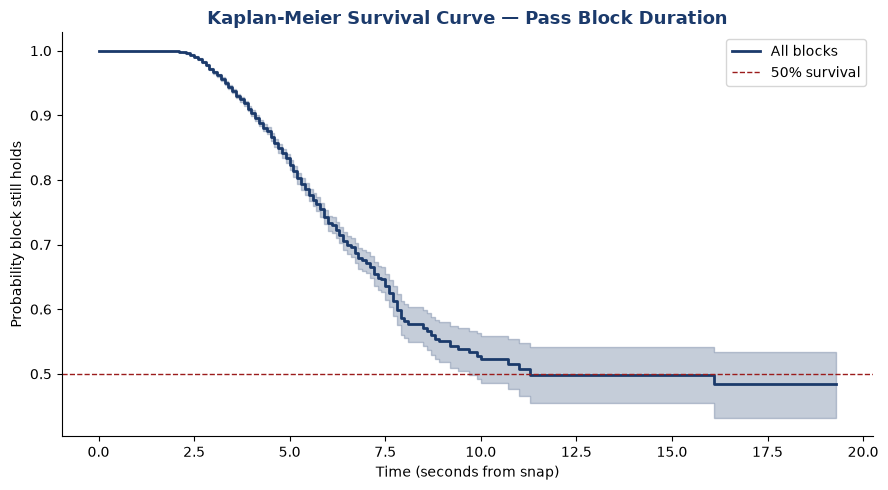

Median survival time : 11.30 seconds
(half of all blocks are still holding at 11.30s after the snap)


In [33]:
# Overall Kaplan-Meier curve
kmf = KaplanMeierFitter()
kmf.fit(
    durations  = ft["duration"],
    event_observed = ft["event"],
    label      = "All blocks"
)

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(
    ax=ax, color=NAVY, linewidth=2,
    ci_show=True
)
ax.set_title("Kaplan-Meier Survival Curve — Pass Block Duration",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Time (seconds from snap)")
ax.set_ylabel("Probability block still holds")
ax.axhline(0.5, color=RED, ls="--", lw=1, label="50% survival")
ax.legend()
plt.tight_layout()
plt.show()

# Median survival time
median_survival = kmf.median_survival_time_
print(f"Median survival time : {median_survival:.2f} seconds")
print(f"(half of all blocks are still holding at {median_survival:.2f}s after the snap)")

##### Step 8: Kaplan-Meier by subgroup

Split the KM curve by position group and backfield flag to see
whether EDA's positional signal (HBs fail more) is visible in the survival curves.

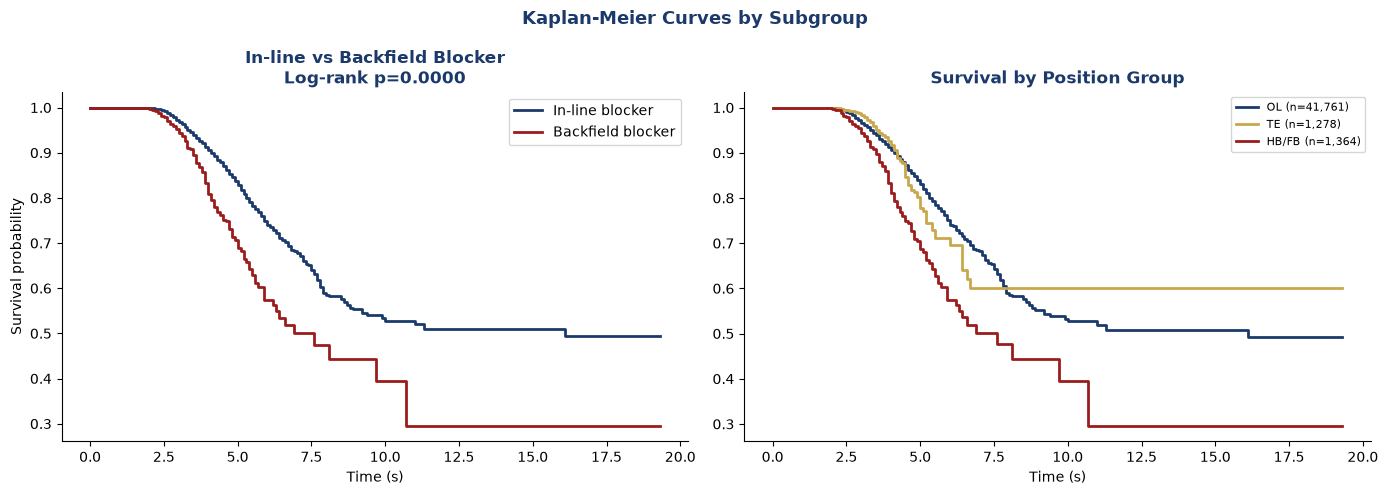

Log-rank p-value (in-line vs backfield): 0.000000
p < 0.05 means the two survival curves are statistically different.


In [34]:
# KM by backfield blocker flag
# EDA: backfield blockers beaten at 5.7% vs in-line 4.2%.
# Survival curve should show backfield blocks failing faster.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: in-line vs backfield
ax = axes[0]
for flag, label, color in [
    (0.0, "In-line blocker",   NAVY),
    (1.0, "Backfield blocker", RED),
]:
    subset = ft[ft["pff_backFieldBlock"] == flag]
    kmf_sub = KaplanMeierFitter()
    kmf_sub.fit(subset["duration"], event_observed=subset["event"], label=label)
    kmf_sub.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

# Log-rank test
inline   = ft[ft["pff_backFieldBlock"] == 0.0]
backfield = ft[ft["pff_backFieldBlock"] == 1.0]
lr = logrank_test(
    inline["duration"],   backfield["duration"],
    inline["event"],      backfield["event"]
)
ax.set_title(f"In-line vs Backfield Blocker\nLog-rank p={lr.p_value:.4f}",
             fontweight="bold", color=NAVY)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Survival probability")
ax.legend()

# Right: by position group (HB / TE / OL)
ax = axes[1]

def pos_group(pos):
    if "HB" in pos or "FB" in pos: return "HB/FB"
    elif "TE" in pos:               return "TE"
    else:                           return "OL"

ft["pos_group"] = ft["pff_positionLinedUp"].apply(pos_group)

for group, color in [("OL", NAVY), ("TE", GOLD), ("HB/FB", RED)]:
    subset = ft[ft["pos_group"] == group]
    kmf_sub = KaplanMeierFitter()
    kmf_sub.fit(subset["duration"], event_observed=subset["event"],
                label=f"{group} (n={len(subset):,})")
    kmf_sub.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

ax.set_title("Survival by Position Group", fontweight="bold", color=NAVY)
ax.set_xlabel("Time (s)")
ax.set_ylabel("")
ax.legend(fontsize=8)

plt.suptitle("Kaplan-Meier Curves by Subgroup",
             fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

print(f"Log-rank p-value (in-line vs backfield): {lr.p_value:.6f}")
print("p < 0.05 means the two survival curves are statistically different.")

##### Step 9: Cox Proportional Hazards model (Cross-Validated)

The Cox model gives each feature a **hazard ratio (HR)**:
- HR > 1 → this feature increases the moment-to-moment risk of failure
- HR < 1 → this feature decreases risk (protective)
- HR = 1 → no effect

**Deliberately excluded:**
- `separation_at_end` — post-outcome, too close to failure
- `window_duration_s` — this IS the duration; including it as a covariate would be circular
- `pff_hitAllowed`, `pff_hurryAllowed`, `pff_sackAllowed` — compose the event flag

In [35]:
# Prepare Cox model input
# Cox requires all-numeric input; encode categoricals.

cox_features = [
    "separation_at_snap",   # how far apart at the snap
    "separation_min",       # closest the rusher ever got
    "closing_velocity",     # how fast the gap closed
    "blocker_speed_mean",
    "blocker_accel_mean",
    "rusher_speed_mean",
    "rusher_speed_max",     # key signal in use case A EDA
    "rusher_accel_mean",
    "pff_backFieldBlock",   # 1 = RB/FB blocker
]

# Encode block type — top 5 types as dummies, rest grouped
TOP_BLOCK_TYPES = ["PP", "PA", "PT", "SW", "CL"]
ft["block_type_simple"] = ft["pff_blockType"].apply(
    lambda x: x if x in TOP_BLOCK_TYPES else "OTHER"
)
block_dummies = pd.get_dummies(
    ft["block_type_simple"], prefix="bt", drop_first=True
)

# gameId travels along for the group split below, then gets dropped before fitting —
# it's an identifier, not a covariate.
cox_df = pd.concat([
    ft[["gameId", "duration", "event"] + cox_features].reset_index(drop=True),
    block_dummies.reset_index(drop=True)
], axis=1).dropna()

print(f"Cox model input : {cox_df.shape}")
print(f"Columns         : {cox_df.columns.tolist()}")

# Group split by gameId — same discipline as every other notebook. Same game =
# correlated blocks (same players, scheme, context), so a row-level split would leak.
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
cox_train_idx, cox_test_idx = next(gss.split(cox_df, groups=cox_df["gameId"]))

cox_train    = cox_df.iloc[cox_train_idx].drop(columns="gameId").reset_index(drop=True)
cox_test     = cox_df.iloc[cox_test_idx].drop(columns="gameId").reset_index(drop=True)
train_groups = cox_df.iloc[cox_train_idx]["gameId"].reset_index(drop=True)

train_game_set = set(cox_df.iloc[cox_train_idx]["gameId"])
test_game_set  = set(cox_df.iloc[cox_test_idx]["gameId"])
print(f"\nTrain: {len(cox_train):,}  Test: {len(cox_test):,}")
print(f"Game overlap (must be 0): {len(train_game_set & test_game_set)}")

Cox model input : (44403, 17)
Columns         : ['gameId', 'duration', 'event', 'separation_at_snap', 'separation_min', 'closing_velocity', 'blocker_speed_mean', 'blocker_accel_mean', 'rusher_speed_mean', 'rusher_speed_max', 'rusher_accel_mean', 'pff_backFieldBlock', 'bt_OTHER', 'bt_PA', 'bt_PP', 'bt_PT', 'bt_SW']

Train: 35,362  Test: 9,041
Game overlap (must be 0): 0


In [36]:
# Fit Cox Proportional Hazards model — GroupKFold cross-validated penalizer search on
# the TRAIN split only, then a final fit on train, scored on the untouched test split.
# (Previously this fit on the entire feature table with a fixed penalizer=0.1 and
# reported an in-sample concordance_index_ — optimistic. Fixed here.)

from sklearn.model_selection import GroupKFold

penalizer_grid = [0.01, 0.05, 0.1, 0.5, 1.0]
cv = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for p in penalizer_grid:
    fold_scores = []
    for tr_idx, val_idx in cv.split(cox_train, groups=train_groups):
        fold_cph = CoxPHFitter(penalizer=p)
        fold_cph.fit(cox_train.iloc[tr_idx], duration_col="duration", event_col="event",
                     show_progress=False)
        fold_scores.append(
            fold_cph.score(cox_train.iloc[val_idx], scoring_method="concordance_index")
        )
    cv_results[p] = (float(np.mean(fold_scores)), float(np.std(fold_scores)))
    print(f"  penalizer={p:<5} CV C-index: {cv_results[p][0]:.4f} ± {cv_results[p][1]:.4f}")

best_penalizer = max(cv_results, key=lambda p: cv_results[p][0])
cv_c_index_mean, cv_c_index_std = cv_results[best_penalizer]
print(f"\nBest penalizer : {best_penalizer}  "
      f"(CV C-index {cv_c_index_mean:.4f} ± {cv_c_index_std:.4f}, 5-fold, grouped by gameId)")

cph = CoxPHFitter(penalizer=best_penalizer)
cph.fit(cox_train, duration_col="duration", event_col="event", show_progress=False)
print("\nCox model fitted on the train split.")
cph.print_summary()

  penalizer=0.01  CV C-index: 0.8030 ± 0.0125
  penalizer=0.05  CV C-index: 0.7701 ± 0.0127
  penalizer=0.1   CV C-index: 0.7541 ± 0.0130
  penalizer=0.5   CV C-index: 0.7272 ± 0.0136
  penalizer=1.0   CV C-index: 0.7213 ± 0.0137

Best penalizer : 0.01  (CV C-index 0.8030 ± 0.0125, 5-fold, grouped by gameId)

Cox model fitted on the train split.


<lifelines.CoxPHFitter: fitted with 35362 total observations, 33017 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 35362
number of events observed = 2345
   partial log-likelihood = -20141.42
         time fit was run = 2026-08-20 20:02:54 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
separation_at_snap -0.24      0.79      0.02           -0.27           -0.20                0.76                0.82
separation_min     -0.88      0.42      0.08           -1.03           -0.73                0.36                0.48
closing_velocity    0.66      1.93      0.04            0.59            0.73                1.80                2.07
blocker_speed_mean  0.19      1.22      0.05            0.10            0.29                1.10                1.34
blocker_accel_mean  0.30      1.36      0.06            0.19            0.42                1.20                1.53
rusher_speed_mean   0.92      2.52      0.04            0.84            1.00                2.32                2.73
rusher_speed_max   -0.30      0.74      0.02           -0.35           -0.25                0.70                0.78
rusher_accel_mean   0.08      1.08      0.04           -0.00            0.16                1.00                1.18
pff_backFieldBlock  0.47      1.60      0.15            0.18            0.77                1.19                2.15
bt_OTHER            0.29      1.33      0.13            0.02            0.55                1.02                1.73
bt_PA              -0.25      0.78      0.08           -0.41           -0.09                0.66                0.92
bt_PP               0.49      1.63      0.06            0.36            0.62                1.44                1.85
bt_PT              -0.08      0.92      0.09           -0.27            0.10                0.76                1.10
bt_SW               0.96      2.62      0.09            0.79            1.14                2.20                3.12

                    cmp to      z      p  -log2(p)
covariate                                         
separation_at_snap    0.00 -12.69 <0.005    120.25
separation_min        0.00 -11.38 <0.005     97.26
closing_velocity      0.00  18.29 <0.005    245.79
blocker_speed_mean    0.00   3.99 <0.005     13.87
blocker_accel_mean    0.00   5.05 <0.005     21.09
rusher_speed_mean     0.00  22.21 <0.005    360.71
rusher_speed_max      0.00 -12.36 <0.005    114.08
rusher_accel_mean     0.00   1.90   0.06      4.14
pff_backFieldBlock    0.00   3.14 <0.005      9.19
bt_OTHER              0.00   2.14   0.03      4.96
bt_PA                 0.00  -3.04 <0.005      8.71
bt_PP                 0.00   7.55 <0.005     44.33
bt_PT                 0.00  -0.90   0.37      1.45
bt_SW                 0.00  10.73 <0.005     86.85
---
Concordance = 0.80
Partial AIC = 40310.85
log-likelihood ratio test = 2242.37 on 14 df
-log2(p) of ll-ratio test = inf

##### Step 10: Hazard ratios (used for interpretation)

In [37]:
# Extract hazard ratios with confidence intervals
# HR > 1 = higher hazard (block fails faster)
# HR < 1 = lower hazard (block is more durable)

hazard_ratios = cph.hazard_ratios_.sort_values(ascending=False)
summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
summary.columns = ["HR", "HR_lower", "HR_upper", "p_value"]
summary = summary.sort_values("HR", ascending=False)

print("Hazard Ratios (HR > 1 = higher risk of block failure):")
print(summary.round(4).to_string())

Hazard Ratios (HR > 1 = higher risk of block failure):
                        HR  HR_lower  HR_upper  p_value
covariate                                              
bt_SW               2.6168    2.1952    3.1193   0.0000
rusher_speed_mean   2.5164    2.3196    2.7299   0.0000
closing_velocity    1.9267    1.7960    2.0670   0.0000
bt_PP               1.6326    1.4374    1.8543   0.0000
pff_backFieldBlock  1.6017    1.1931    2.1502   0.0017
blocker_accel_mean  1.3558    1.2046    1.5259   0.0000
bt_OTHER            1.3315    1.0247    1.7302   0.0321
blocker_speed_mean  1.2152    1.1042    1.3373   0.0001
rusher_accel_mean   1.0831    0.9977    1.1757   0.0568
bt_PT               0.9186    0.7638    1.1048   0.3673
separation_at_snap  0.7886    0.7602    0.8181   0.0000
bt_PA               0.7800    0.6645    0.9156   0.0024
rusher_speed_max    0.7391    0.7044    0.7754   0.0000
separation_min      0.4163    0.3579    0.4841   0.0000


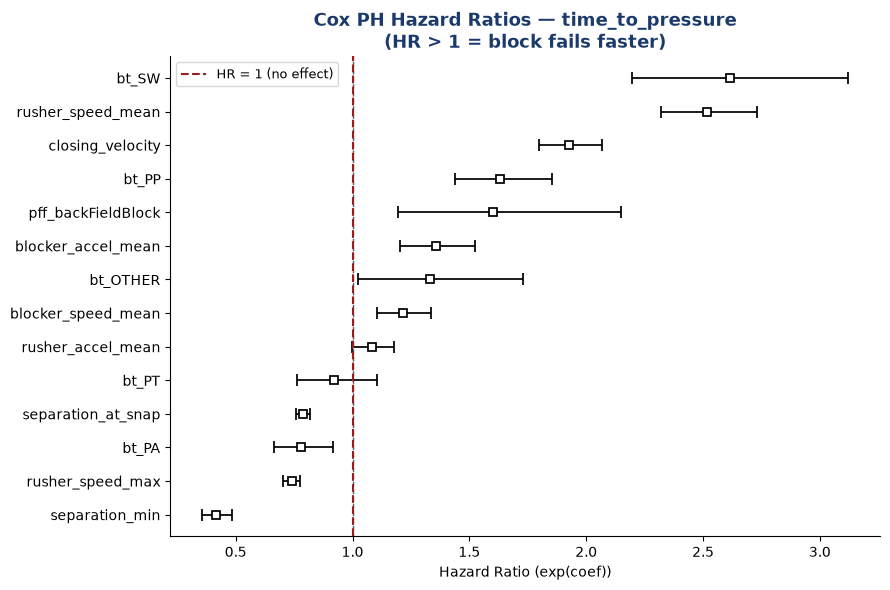

In [38]:
# Forest plot of hazard ratios
fig, ax = plt.subplots(figsize=(9, 6))
cph.plot(
    ax=ax,
    hazard_ratios=True,
    capsize=4,
)
ax.axvline(1.0, color=RED, ls="--", lw=1.5, label="HR = 1 (no effect)")
ax.set_title("Cox PH Hazard Ratios — time_to_pressure\n(HR > 1 = block fails faster)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Hazard Ratio (exp(coef))")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### Step 11: Concordance index (used for evaluation)

The concordance index (C-index) is the survival analysis equivalent of ROC-AUC.
It measures how often the model correctly ranks two assignments by failure risk:
C = 0.5 is random; C = 1.0 is perfect.

In [39]:
test_c_index = cph.score(cox_test, scoring_method="concordance_index")
c_index = test_c_index  # kept as `c_index` for the cells/metrics below

print(f"CV C-index (train, 5-fold)  : {cv_c_index_mean:.4f} ± {cv_c_index_std:.4f}")
print(f"Held-out test C-index       : {test_c_index:.4f}")
print(f"Random baseline             : 0.5000")
print(f"Lift over random            : +{test_c_index - 0.5:.4f}")
print()
print("Interpretation:")
print(f"  For any two random held-out assignments, the model correctly")
print(f"  identifies which one failed sooner {test_c_index:.1%} of the time.")
print()
print("Cross-use case comparison:")
print(f"  use case A ROC-AUC (binary classifier) : see artifacts/pressure_allowed/")
print(f"  use case E C-index (survival model)    : {test_c_index:.4f}")
print(f"  Similar values confirm both models find the same real signal.")

CV C-index (train, 5-fold)  : 0.8030 ± 0.0125
Held-out test C-index       : 0.8028
Random baseline             : 0.5000
Lift over random            : +0.3028

Interpretation:
  For any two random held-out assignments, the model correctly
  identifies which one failed sooner 80.3% of the time.

Cross-use case comparison:
  use case A ROC-AUC (binary classifier) : see artifacts/pressure_allowed/
  use case E C-index (survival model)    : 0.8028
  Similar values confirm both models find the same real signal.


##### Step 12: Error analysis — shortest vs longest surviving blocks

In [40]:
# Predicted partial hazard per assignment — scored on the held-out test split.
# Higher partial hazard = model thinks this block is at higher risk.
ft_scored = cox_test.copy()
ft_scored["partial_hazard"] = cph.predict_partial_hazard(cox_test)

# Quartile breakdown: do high-hazard assignments actually fail faster?
ft_scored["hazard_quartile"] = pd.qcut(
    ft_scored["partial_hazard"], q=4, labels=["Q1 (safest)","Q2","Q3","Q4 (riskiest)"]
)

quartile_summary = (
    ft_scored.groupby("hazard_quartile", observed=True)
    .agg(
        n               =("event", "count"),
        failure_rate    =("event", "mean"),
        mean_duration   =("duration", "mean"),
        mean_sep_min    =("separation_min", "mean"),
        mean_rusher_spd =("rusher_speed_max", "mean"),
    )
    .round(3)
)
print("Quartile analysis by predicted hazard (held-out test set):")
print(quartile_summary.to_string())

Quartile analysis by predicted hazard (held-out test set):
                    n  failure_rate  mean_duration  mean_sep_min  mean_rusher_spd
hazard_quartile                                                                  
Q1 (safest)      2261         0.027          3.732         1.037            3.537
Q2               2260         0.046          3.347         0.826            3.616
Q3               2260         0.078          3.012         0.742            3.865
Q4 (riskiest)    2260         0.116          2.728         0.653            4.651


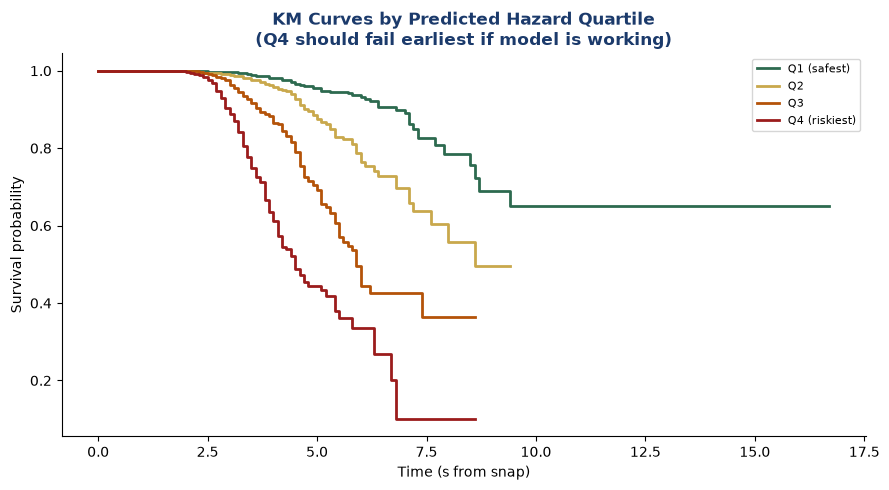

In [41]:
# KM curves by predicted hazard quartile
# If the model is calibrated, Q4 (riskiest) should fail earliest.

fig, ax = plt.subplots(figsize=(9, 5))
colors_q = [GREEN, GOLD, AMBER, RED]
for (q, group), color in zip(ft_scored.groupby("hazard_quartile", observed=True), colors_q):
    kmf_q = KaplanMeierFitter()
    kmf_q.fit(group["duration"], event_observed=group["event"], label=str(q))
    kmf_q.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

ax.set_title("KM Curves by Predicted Hazard Quartile\n(Q4 should fail earliest if model is working)",
             fontsize=12, fontweight="bold", color=NAVY)
ax.set_xlabel("Time (s from snap)")
ax.set_ylabel("Survival probability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

<!-- CONCLUSION_CELL_11 -->

##### Step 13: Save & Summary

In [42]:
# Save artifacts
joblib.dump(cph, ARTIFACT_DIR / "cox_model.joblib")
joblib.dump(kmf, ARTIFACT_DIR / "km_overall.joblib")

ft.to_parquet(ARTIFACT_DIR / "feature_table.parquet", index=False)

summary.reset_index().rename(columns={"index":"feature"})\
       .to_csv(ARTIFACT_DIR / "hazard_ratios.csv", index=False)

metrics = {
    "c_index"             : round(float(c_index), 4),          # == held-out test C-index
    "test_c_index"         : round(float(test_c_index), 4),
    "cv_c_index_mean"      : round(float(cv_c_index_mean), 4),
    "cv_c_index_std"       : round(float(cv_c_index_std), 4),
    "penalizer"            : best_penalizer,
    "median_survival_s"   : round(float(median_survival), 3),
    "n_events"            : int(pos),
    "n_censored"          : int(neg),
    "event_rate"          : round(float(pos / len(ft)), 4),
    "duration_proxy"      : "window_duration_s (snap to terminal event)",
    "excluded_features"   : ["separation_at_end", "window_duration_s", 
                              "pff_hitAllowed", "pff_hurryAllowed", "pff_sackAllowed"],
    "model"               : "CoxPHFitter (lifelines), penalizer tuned via 5-fold GroupKFold CV",
}
with open(ARTIFACT_DIR / "metrics_report.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name}")

Saved:
  cox_model.joblib
  feature_table.parquet
  hazard_ratios.csv
  km_overall.joblib
  metrics_report.json


In [43]:
print("═" * 62)
print("time_to_pressure RESULTS SUMMARY")
print("═" * 62)
print(f"  Assignments     : {len(ft):,} (same population as use case A)")
print(f"  Events          : {pos:,} ({pos/len(ft):.1%})")
print(f"  Censored        : {neg:,} ({neg/len(ft):.1%})")
print(f"  Median survival : {median_survival:.2f} seconds after snap")
print(f"  C-index         : {c_index:.4f}   (0.5 = random, 1.0 = perfect)")
top_hr = summary["HR"].idxmax()
print(f"  Highest HR: {top_hr} = {summary.loc[top_hr,'HR']:.3f}")
print(f"  (this feature multiplies per-second failure risk by {summary.loc[top_hr,'HR']:.2f}x)")
print("═" * 62)

══════════════════════════════════════════════════════════════
time_to_pressure RESULTS SUMMARY
══════════════════════════════════════════════════════════════
  Assignments     : 44,403 (same population as use case A)
  Events          : 2,949 (6.6%)
  Censored        : 41,454 (93.4%)
  Median survival : 11.30 seconds after snap
  C-index         : 0.8028   (0.5 = random, 1.0 = perfect)
  Highest HR: bt_SW = 2.617
  (this feature multiplies per-second failure risk by 2.62x)
══════════════════════════════════════════════════════════════


<!-- CONCLUSION_CELL_12 -->